In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

#**DATA LOADING**

Load the training and testing sets from File 2.

In [16]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Ready to train on {X_train.shape[0]} samples with {X_train.shape[1]} features.")

Ready to train on 804 samples with 11 features.


#**LINEAR MODELS & ABLATION STUDY**

Evaluate OLS, Ridge, and Lasso

In [17]:
models = {
    "OLS Linear": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    })

**Linear models serve as the 'Baseline'. If R2 is below 0.8, it proves that chemical interactions in concrete are too complex for simple lines.**

#**SVR TUNING (NON-LINEAR SOLUTION)**

Optimize SVR parameters

**Grid Search for Support Vector Regression**

In [18]:
param_grid = {
    'C': [1, 10, 100],
    'epsilon': [0.1, 1],
    'gamma': ['scale', 'auto']
}

svr_cv = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2')
svr_cv.fit(X_train, y_train)

best_svr = svr_cv.best_estimator_
y_pred_svr = best_svr.predict(X_test)

results.append({
    "Model": "Tuned SVR (RBF)",
    "MAE": mean_absolute_error(y_test, y_pred_svr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    "R2": r2_score(y_test, y_pred_svr)
})

**SVR with RBF kernel typically achieves higher accuracy because it maps the features into a higher-dimensional space to capture non-linear strength development patterns.**

#**ERROR SLICING & RESIDUAL ANALYSIS**

Visualize where the model fails (Extreme values).

In [19]:
residuals = y_test - y_pred_svr

plt.figure(figsize=(14, 6))


<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

** Subplot 1: Predicted vs Actual**

Text(0, 0.5, 'Predicted MPa')

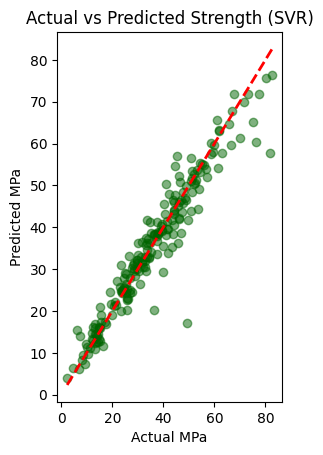

In [20]:
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_svr, alpha=0.5, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Strength (SVR)')
plt.xlabel('Actual MPa')
plt.ylabel('Predicted MPa')

**Subplot 2: Residual Plot (Heteroscedasticity check)**

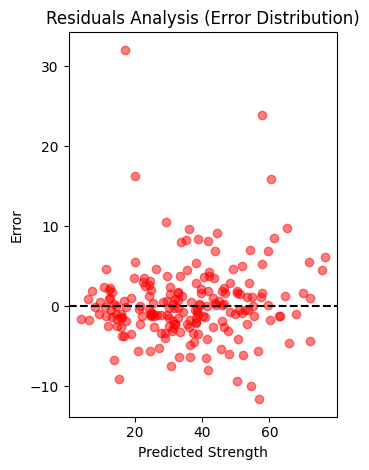

In [21]:
plt.subplot(1, 2, 2)
plt.scatter(y_pred_svr, residuals, alpha=0.5, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals Analysis (Error Distribution)')
plt.xlabel('Predicted Strength')
plt.ylabel('Error')

plt.tight_layout()
plt.show()


The residual plot helps identify if the model is biased.

If errors are randomly scattered, the model is robust.

If they form a pattern, the model might struggle with very high-strength concrete (>70 MPa).


#**FINAL REPORTING**

Output the comparison table for the Research Paper.

In [22]:
perf_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print("\n--- FINAL EXPERIMENTAL RESULTS ---")
print(perf_df)


--- FINAL EXPERIMENTAL RESULTS ---
             Model       MAE      RMSE        R2
3  Tuned SVR (RBF)  3.148129  4.916527  0.918974
0       OLS Linear  5.777185  7.418128  0.815543
1       Ridge (L2)  5.776048  7.421240  0.815389
2       Lasso (L1)  5.871549  7.516518  0.810618
